<a href="https://colab.research.google.com/github/KirrtanaaNallathamby/deep-learning-product-recognition/blob/main/DeepLearning_IndAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning Individual Assignment**
## Kirrtanaa Nallathamby
## 23004921

# **Part A**

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kirrrrrrr","key":"270879d53ff043714e03301cff00fae2"}'}

In [2]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
# Download and extract Malaysian food dataset from Kaggle

!kaggle datasets download -d karkengchan/malaysia-food-11
!unzip malaysia-food-11.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/mixed_rice/0.jpg  
  inflating: dataset/mixed_rice/1.jpg  
  inflating: dataset/mixed_rice/10.jpg  
  inflating: dataset/mixed_rice/100.jpg  
  inflating: dataset/mixed_rice/101.jpg  
  inflating: dataset/mixed_rice/102.jpg  
  inflating: dataset/mixed_rice/103.jpg  
  inflating: dataset/mixed_rice/104.jpg  
  inflating: dataset/mixed_rice/105.jpg  
  inflating: dataset/mixed_rice/106.jpg  
  inflating: dataset/mixed_rice/107.jpg  
  inflating: dataset/mixed_rice/108.jpg  
  inflating: dataset/mixed_rice/109.jpg  
  inflating: dataset/mixed_rice/11.jpg  
  inflating: dataset/mixed_rice/110.jpg  
  inflating: dataset/mixed_rice/111.jpg  
  inflating: dataset/mixed_rice/112.jpg  
  inflating: dataset/mixed_rice/113.jpg  
  inflating: dataset/mixed_rice/114.jpg  
  inflating: dataset/mixed_rice/115.jpg  
  inflating: dataset/mixed_rice/116.jpg  
  inflating: dataset/mixed_rice/117.jpg  
  inflating: dataset/mixed_rice

In [4]:
import os
print(os.listdir("dataset"))

['fried_rice', 'hamburger', 'nasi_lemak', 'fried_noodles', 'mixed_rice', 'laksa', 'fish_and_chips', 'roti_canai', 'popiah', 'kaya_toast', 'satay']


In [5]:
selected_classes = ["nasi_lemak","laksa","roti_canai","popiah","satay"]

In [6]:
# Create folder structure
import os

base_dir = "data"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

for category in selected_classes:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(val_dir, category), exist_ok=True)

In [7]:
# Split dataset (80:20)
import shutil
import random

source_dir = "dataset"

for category in selected_classes:
    images = os.listdir(os.path.join(source_dir, category))
    random.shuffle(images)

    split = int(0.8 * len(images))

    for img in images[:split]:
        shutil.copy(os.path.join(source_dir, category, img),
                    os.path.join(train_dir, category, img))

    for img in images[split:]:
        shutil.copy(os.path.join(source_dir, category, img),
                    os.path.join(val_dir, category, img))

In [8]:
# Remove corrupted images
from PIL import Image

def clean_dataset(folder):
    for category in os.listdir(folder):
        path = os.path.join(folder, category)
        for img in os.listdir(path):
            img_path = os.path.join(path, img)
            try:
                with Image.open(img_path) as im:
                    im.verify()
            except:
                os.remove(img_path)

clean_dataset("data/train")
clean_dataset("data/val")

In [9]:
# Check number of images
for category in selected_classes:
    print(category)
    print("Train:", len(os.listdir(os.path.join(train_dir, category))))
    print("Val:", len(os.listdir(os.path.join(val_dir, category))))
    print()

nasi_lemak
Train: 799
Val: 200

laksa
Train: 800
Val: 200

roti_canai
Train: 800
Val: 200

popiah
Train: 800
Val: 200

satay
Train: 800
Val: 200



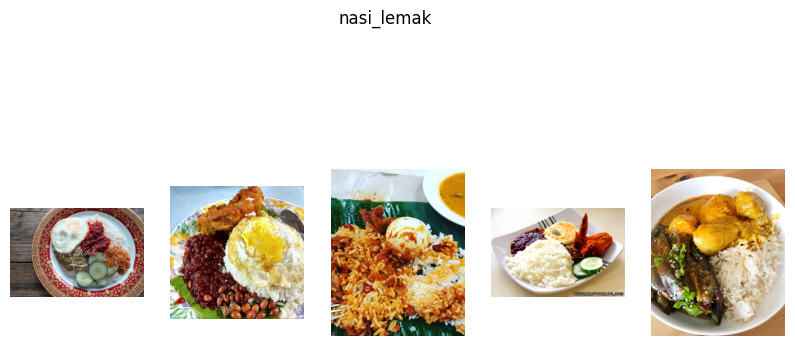

In [11]:
# Display sample images from dataset
import matplotlib.pyplot as plt
import os
import cv2

category = "nasi_lemak"
folder = os.path.join("data/train", category)

images = os.listdir(folder)[:5]

plt.figure(figsize=(10,5))

for i, img in enumerate(images):
    image = cv2.imread(os.path.join(folder, img))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis('off')

plt.suptitle(category)
plt.show()

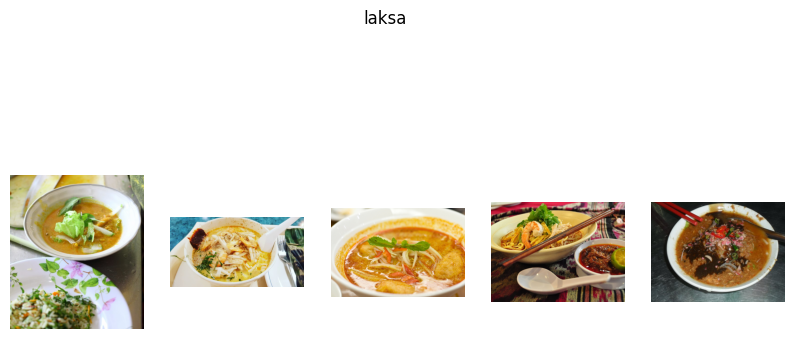

In [12]:
import matplotlib.pyplot as plt
import os
import cv2

category = "laksa"
folder = os.path.join("data/train", category)

images = os.listdir(folder)[:5]

plt.figure(figsize=(10,5))

for i, img in enumerate(images):
    image = cv2.imread(os.path.join(folder, img))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis('off')

plt.suptitle(category)
plt.show()

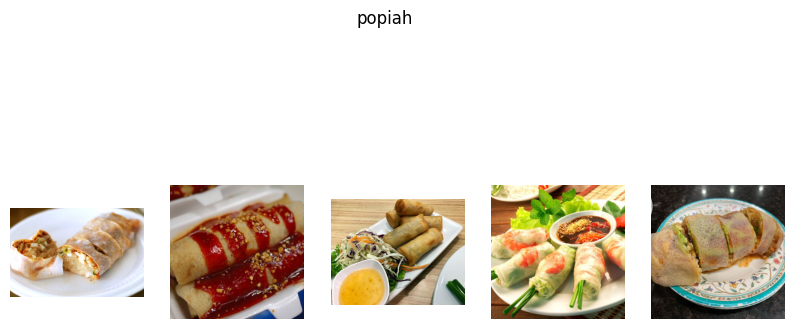

In [13]:
import matplotlib.pyplot as plt
import os
import cv2

category = "popiah"
folder = os.path.join("data/train", category)

images = os.listdir(folder)[:5]

plt.figure(figsize=(10,5))

for i, img in enumerate(images):
    image = cv2.imread(os.path.join(folder, img))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis('off')

plt.suptitle(category)
plt.show()

# **Part B**

In [14]:
# Prepare data for CNN
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "data/train", target_size=(224,224),
    batch_size=32, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "data/val", target_size=(224,224),
    batch_size=32, class_mode='categorical'
)

Found 3999 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


In [15]:
# Build CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(5,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Show parameter count and layer shapes
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,901 (9.92 MB)

 Trainable params: 2,600,901 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
import time

start_time = time.time()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

end_time = time.time()
print("CNN Training Time:", end_time - start_time, "seconds")

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 116s 858ms/step - accuracy: 0.3161 - loss: 1.5018 - val_accuracy: 0.4660 - val_loss: 1.2894
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 99s 792ms/step - accuracy: 0.4614 - loss: 1.2973 - val_accuracy: 0.4940 - val_loss: 1.2112
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 105s 840ms/step - accuracy: 0.5281 - loss: 1.1718 - val_accuracy: 0.5990 - val_loss: 1.0507
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 103s 827ms/step - accuracy: 0.5644 - loss: 1.0963 - val_accuracy: 0.6110 - val_loss: 0.9998
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 107s 851ms/step - accuracy: 0.6254 - loss: 0.9664 - val_accuracy: 0.6330 - val_loss: 0.9317
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 103s 827ms/step - accuracy: 0.6392 - loss: 0.9289 - val_accuracy: 0.5900 - val_loss: 0.9917
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 104s 837ms/step - accuracy: 0.6704 - loss: 0.8839 - val_accuracy: 0.6620 - val_loss: 0.8773
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 105s 842ms/step - accuracy: 0.6789 - 

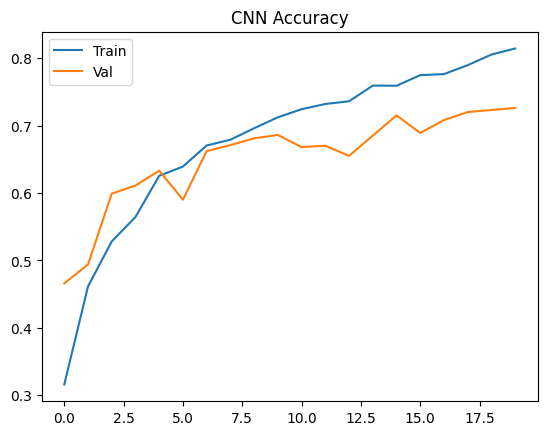

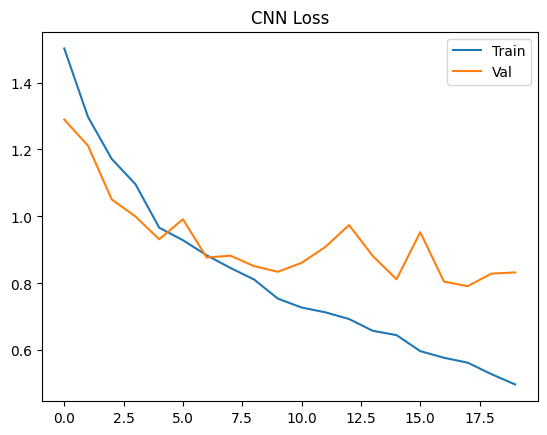

In [18]:
# Plot training and validation accuracy and loss for CNN
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.title("CNN Loss")
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 571ms/step


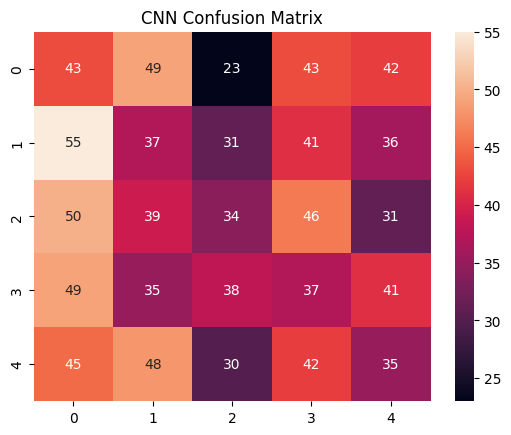

In [19]:
# Evaluate CNN performance using confussion matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_generator.reset()
pred = model.predict(val_generator)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.show()

In [23]:
# Print final CNN accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print("CNN Final Training Accuracy:", final_train_acc)
print("CNN Final Validation Accuracy:", final_val_acc)

CNN Final Training Accuracy: 0.8142035603523254
CNN Final Validation Accuracy: 0.7260000109672546


# **Part C**

In [24]:
# Prepare data generates with ResNet-specific preprocessing
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    "data/train", target_size=(224,224),
    batch_size=32, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "data/val", target_size=(224,224),
    batch_size=32, class_mode='categorical'
)

Found 3999 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


In [25]:
# Load pre-trained ResNet50 and custom classification layers
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
# Train transfer learning model using ResNet
start_time = time.time()

history_resnet = model_resnet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

resnet_time = time.time() - start_time
print("ResNet Training Time:", resnet_time)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 126s 907ms/step - accuracy: 0.6959 - loss: 0.8301 - val_accuracy: 0.8590 - val_loss: 0.4571
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 104s 831ms/step - accuracy: 0.8625 - loss: 0.4096 - val_accuracy: 0.8750 - val_loss: 0.3893
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 105s 841ms/step - accuracy: 0.8945 - loss: 0.3261 - val_accuracy: 0.8940 - val_loss: 0.3572
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 104s 834ms/step - accuracy: 0.9050 - loss: 0.2839 - val_accuracy: 0.8940 - val_loss: 0.3495
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 104s 831ms/step - accuracy: 0.9190 - loss: 0.2571 - val_accuracy: 0.8990 - val_loss: 0.3290
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 108s 864ms/step - accuracy: 0.9255 - loss: 0.2317 - val_accuracy: 0.9050 - val_loss: 0.3178
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 895ms/step - accuracy: 0.9287 - loss: 0.2162 - val_accuracy: 0.8940 - val_loss: 0.3349
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 114s 907ms/step - accuracy: 0.9317 -

In [27]:
# Print final ResNet accuracy
final_train_acc_resnet = history_resnet.history['accuracy'][-1]
final_val_acc_resnet = history_resnet.history['val_accuracy'][-1]

print("ResNet Final Training Accuracy:", final_train_acc_resnet)
print("ResNet Final Validation Accuracy:", final_val_acc_resnet)

ResNet Final Training Accuracy: 0.9412353038787842
ResNet Final Validation Accuracy: 0.9070000052452087


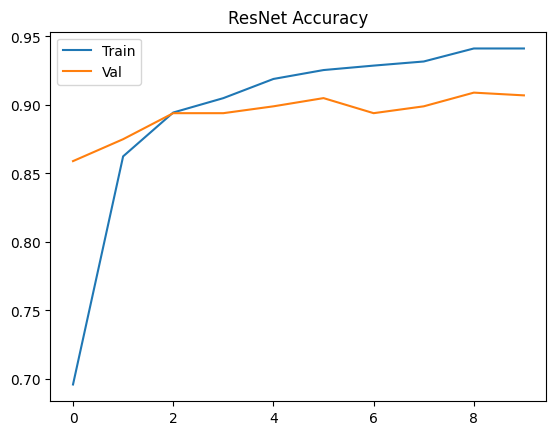

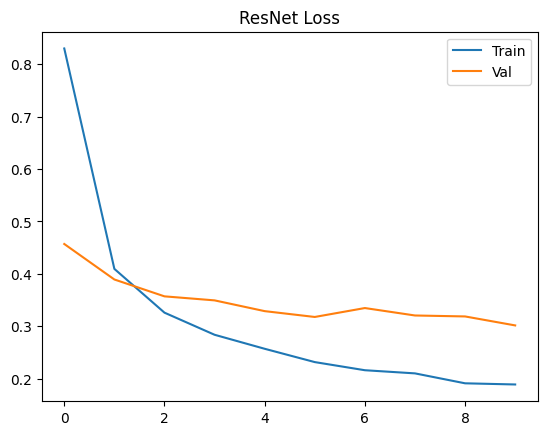

In [28]:
# Plot training and validation performance for ResNet
plt.plot(history_resnet.history['accuracy'], label='Train')
plt.plot(history_resnet.history['val_accuracy'], label='Val')
plt.legend()
plt.title("ResNet Accuracy")
plt.show()

plt.plot(history_resnet.history['loss'], label='Train')
plt.plot(history_resnet.history['val_loss'], label='Val')
plt.legend()
plt.title("ResNet Loss")
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 540ms/step


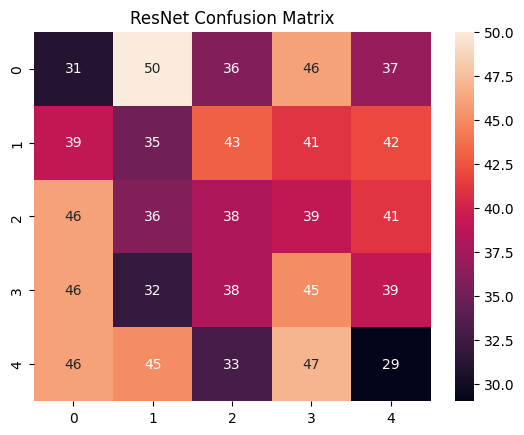

In [29]:
# Evaluate ResNet performance using confusion matrix
val_generator.reset()
pred = model_resnet.predict(val_generator)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("ResNet Confusion Matrix")
plt.show()

# **Part D**

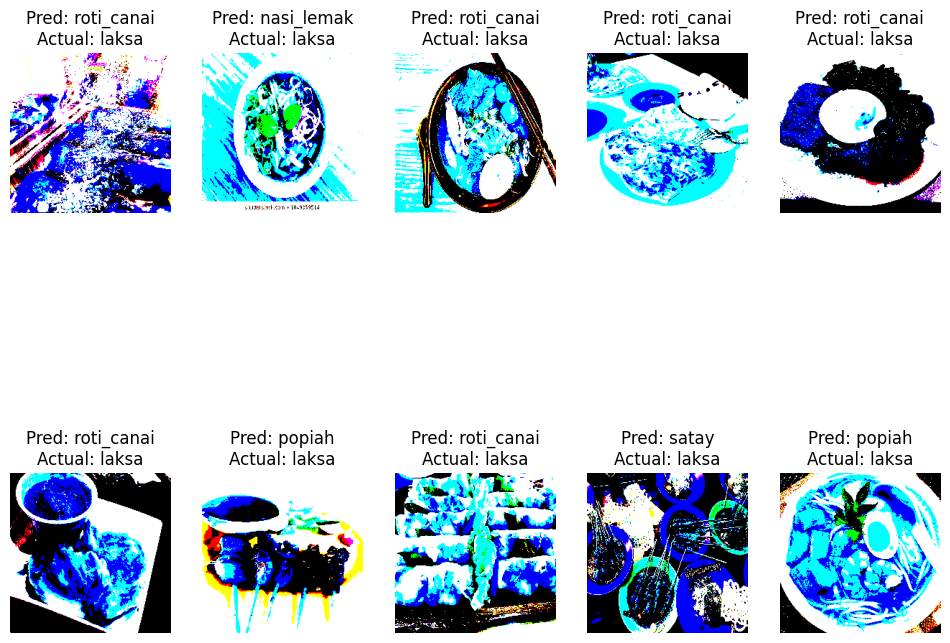

In [30]:
# Display examples of misclassified images for error analysis
misclassified = np.where(y_pred != val_generator.classes)[0]

plt.figure(figsize=(12,10))
class_labels = list(val_generator.class_indices.keys())

for i, idx in enumerate(misclassified[:10]):
    img, label = val_generator[idx]
    plt.subplot(2,5,i+1)
    plt.imshow(img[0])
    plt.title(f"Pred: {class_labels[y_pred[idx]]}\nActual: {class_labels[val_generator.classes[idx]]}")
    plt.axis('off')

plt.show()

In [37]:
import pandas as pd

cnn_time_val = 2098.1600
resnet_time_val = 1094.5844

data = {
    "Metric": ["Final Val Accuracy", "Training Time (s)", "Epochs"],
    "Custom CNN": [
        history.history['val_accuracy'][-1],
        cnn_time_val,
        20
    ],
    "ResNet-50": [
        history_resnet.history['val_accuracy'][-1],
        resnet_time_val,
        10
    ]
}

df = pd.DataFrame(data)
print(df)

               Metric  Custom CNN  ResNet-50
0  Final Val Accuracy       0.726     0.9070
1   Training Time (s)    2098.160  1094.5844
2              Epochs      20.000    10.0000
